The following is an analysis based on data from a dataset dubbed "Social Media Impact on Teen Mental Health", from the website 'Kaggle' which was used by the author for their own AI training. Although presumably from a real source, the author of the data does not give credit to the source which the data was taken from, nor what methods were used in collecting this data, meaning all conclusions based on this data should at best be taken as hypothetical.

In [46]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output



def read_csv(filename: str):
    csv_path = Path("data") / filename
    df = pd.read_csv(csv_path)
    return df

def group_by_gender(data :pd.DataFrame): #returns groupby object
    out = data.groupby("gender")
    return out

df = read_csv("Teen_Mental_Health_Dataset.csv")

print(f"The shape of the data is as follows: {df.shape}, meaning {df.shape[0]} entries, and {df.shape[1]} fields.\n")
print("The following fields of the data contain various formats, as can be seen with the following:")
print(df.info())
print("\nAs the dataset used is already cleaned there are no null entries, as can be seen following:")
print(df.isnull().sum())
print("\nFurther summary of the data, such as mean values and standard deviations for each of the fields, can be seen in following, although further analysis will be saved for later:")
print(df.describe())





The shape of the data is as follows: (1200, 13), meaning 1200 entries, and 13 fields.

The following fields of the data contain various formats, as can be seen with the following:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addi

(Since the dataset is already cleaned there is no need to clean it again, but if not, we could simply use the existing pandas function "df.dropna()" to drop all entries which are missing any data, and continue any future operations on the output given)

Since we do have quite a robust dataset (the admission of how it was collected aside), it can also be utilized to answer a few questions. The original author from where the data was published utilized it to train an AI model to predict depression.

We, of course, do not have a trained AI at hand, so we will limit our analysis to what the dataset can answer through traditional data analysis methods.

Although there are quite a few things which the dataset lends itself to examine, we will limit it to a pretty straight forward hypothesis, that a greater amount of social media usage has a negative impact on teens, measured here through factors such as academic performance and depression, we will also examine whether aspects such as gender could be a confluencing factor.

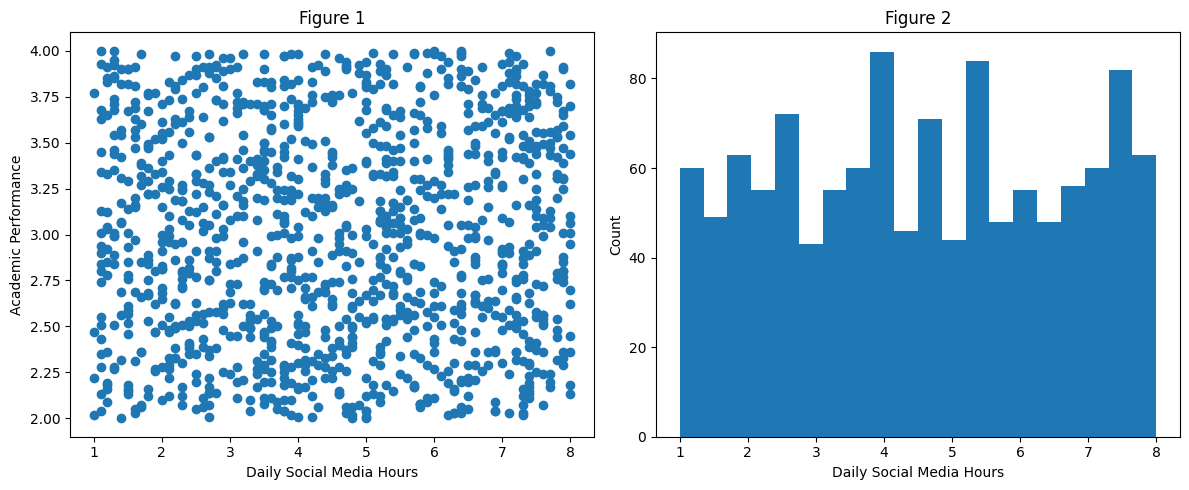

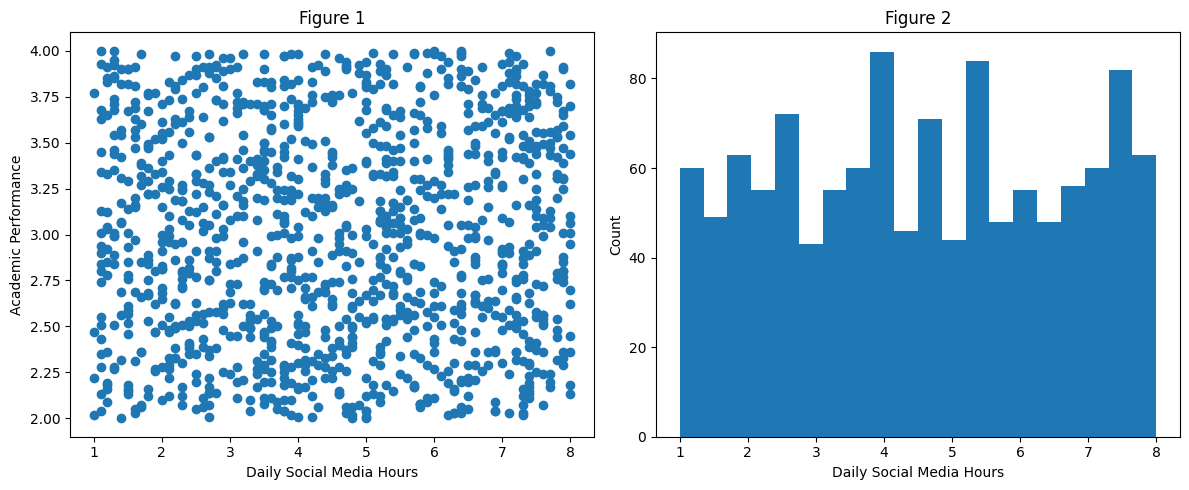

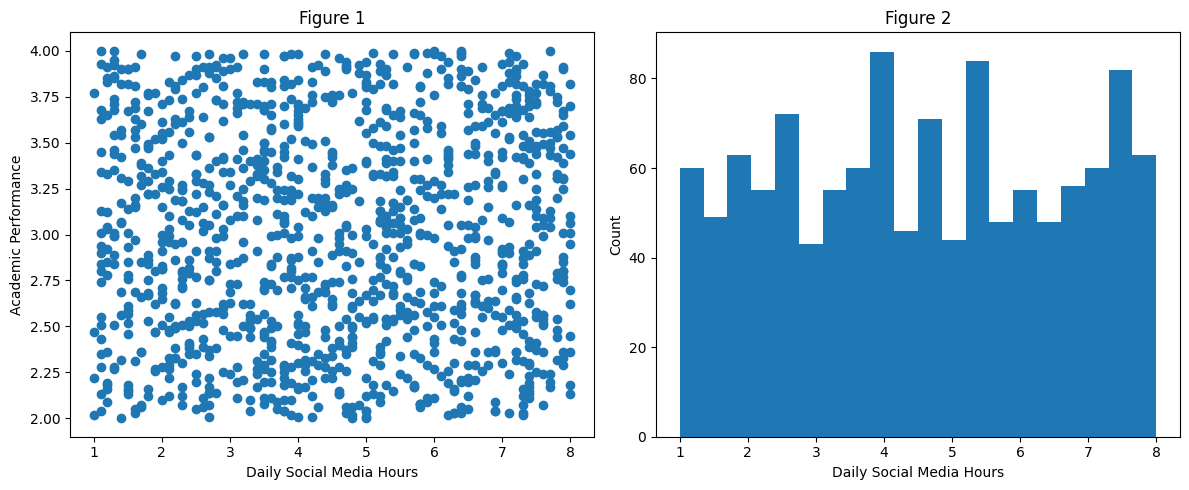

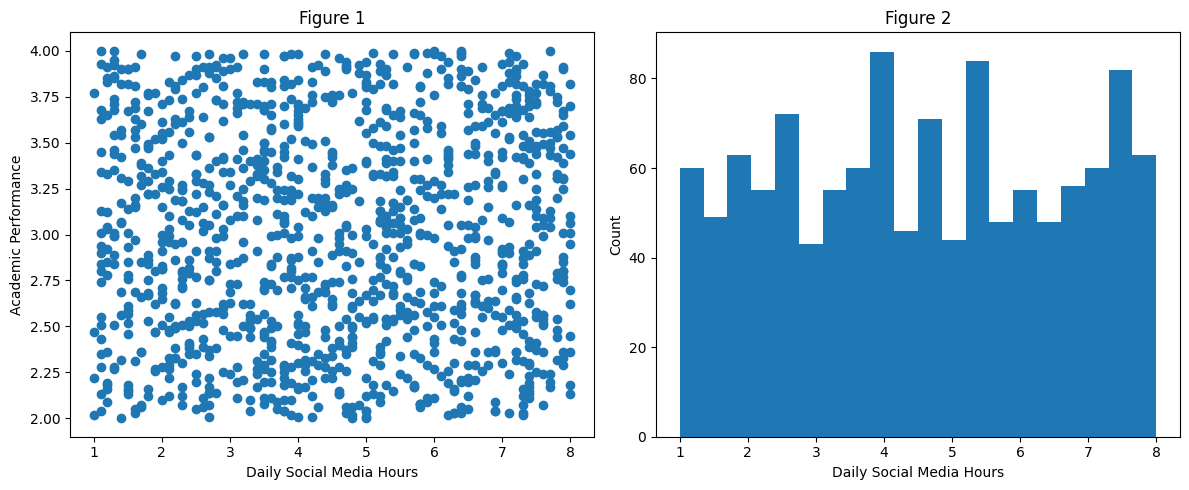

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Scatter plot
axes[0].scatter(df["daily_social_media_hours"], df["academic_performance"])
axes[0].set_title("Figure 1")
axes[0].set_xlabel("Daily Social Media Hours")
axes[0].set_ylabel("Academic Performance")

#Histogram
axes[1].hist(df["daily_social_media_hours"], bins=20)
axes[1].set_title("Figure 2")
axes[1].set_xlabel("Daily Social Media Hours")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [54]:
def group_by_gender(data :pd.DataFrame): #returns groupby object
    out = data.groupby("gender")
    return out

grouped = group_by_gender(df)
for gender, group in grouped:
        print(f"\nGroup: {gender}")
        print(group)


Group: female
      age  gender  daily_social_media_hours platform_usage  sleep_hours  \
1      19  female                       1.9         TikTok          8.0   
2      17  female                       1.3      Instagram          7.6   
4      15  female                       4.7           Both          4.9   
5      19  female                       7.4           Both          4.4   
6      18  female                       2.5      Instagram          6.4   
...   ...     ...                       ...            ...          ...   
1190   17  female                       3.8      Instagram          8.4   
1193   13  female                       7.2      Instagram          8.1   
1195   18  female                       6.8      Instagram          6.6   
1197   14  female                       1.7           Both          8.7   
1199   16  female                       4.7         TikTok          6.5   

      screen_time_before_sleep  academic_performance  physical_activity  \
1        